# 1. Diabetes Dataset – Missing Value Imputation & Encoding

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('diabetes.csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [3]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


In [4]:
df[['BMI','Glucose','BloodPressure']]=df[['BMI','Glucose','BloodPressure']].replace(0, np.nan)

df.isnull().sum()

,0
Pregnancies,0
Glucose,5
BloodPressure,35
SkinThickness,0
Insulin,0
BMI,11
DiabetesPedigreeFunction,0
Age,0
Outcome,0


<Axes: xlabel='Glucose', ylabel='Count'>

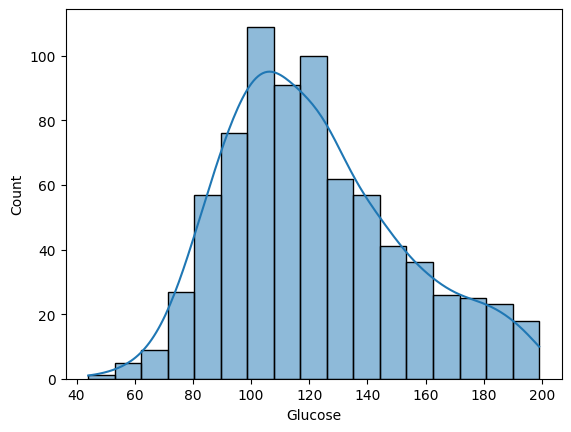

In [5]:
import seaborn as sns
sns.histplot(data = df['Glucose'],kde=True)

In [6]:
# right skewed data
# using median
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(df[['Glucose']])
df['Glucose'] = imputer.transform(df[['Glucose']]).ravel()

<Axes: xlabel='BloodPressure', ylabel='Count'>

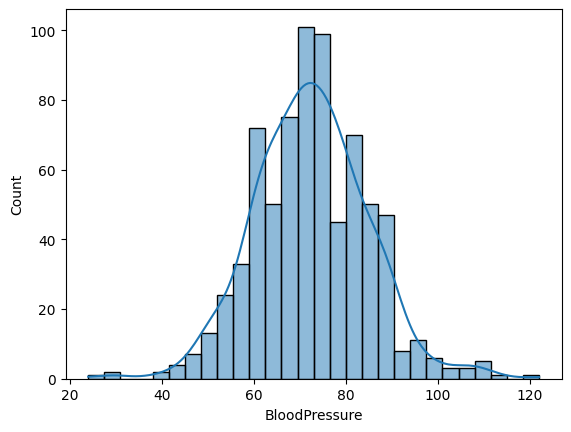

In [7]:
sns.histplot(data = df['BloodPressure'],kde=True)

In [8]:
# normal distribution. will use mean

imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
imputer.fit(df[['BloodPressure']])
df['BloodPressure'] = imputer.transform(df[['BloodPressure']]).ravel()
df['BloodPressure'].isnull().sum()

np.int64(0)

<Axes: xlabel='BMI', ylabel='Count'>

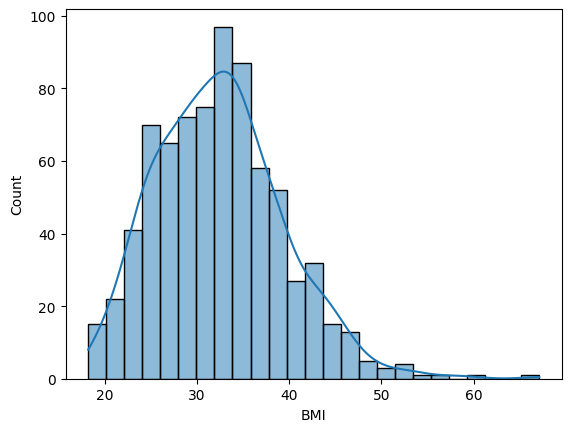

In [9]:
sns.histplot(data = df['BMI'],kde=True)

In [10]:
# right skewed. use median
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
imputer.fit(df[['BMI']])
df['BMI'] = imputer.transform(df[['BMI']]).ravel()
df['BMI'].isnull().sum()

np.int64(0)

In [11]:
df['Age']

,Age
0,50
1,31
2,32
3,21
4,33
...,...
763,63
764,27
765,30
766,47


In [12]:
df.loc[df['Age']<30, 'Age_group'] = 'Young'
df.loc[(df['Age']>=30) & (df['Age']<=50), 'Age_group']='Adult'
df.loc[df['Age']>50, 'Age_group']='Senior'
df['Age_group']

,Age_group
0,Adult
1,Adult
2,Adult
3,Young
4,Adult
...,...
763,Senior
764,Young
765,Adult
766,Adult


In [13]:
# orderded data -> ordinal encoding will be used
from sklearn.preprocessing import OrdinalEncoder
age_enc = OrdinalEncoder(categories=[['Young','Adult','Senior']])
age_enc.fit(df[['Age_group']])
df['Age_group'] = age_enc.transform(df[['Age_group']]).ravel()

In [14]:
df['Age_group']

,Age_group
0,1.0
1,1.0
2,1.0
3,0.0
4,1.0
...,...
763,2.0
764,0.0
765,1.0
766,1.0


# 2. Heart Disease Dataset – One Hot Encoding

In [15]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "johnsmith88/heart-disease-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)



/tmp/ipykernel_635/701758525.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 37.2k/37.2k [00:00<00:00, 43.0MB/s]


In [16]:
df.head(5)

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [17]:
categorical_columns = ['sex','cp','fbs','restecg','exang','slope','ca','thal','target']


In [18]:
from sklearn.preprocessing import OneHotEncoder
encoder_cp = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoder_cp.fit(df[['cp']])
encoded_cp = encoder_cp.transform(df[['cp']])

encoder_thal = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoder_thal.fit(df[['thal']])
encoded_thal = encoder_thal.transform(df[['thal']])

df = pd.concat([df, encoded_cp, encoded_thal],axis=1)
np.shape(df)

(1025, 22)

# 3. Tips Dataset – Label Encoding

In [19]:
import seaborn as sns

df = sns.load_dataset("tips")

In [20]:
df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4
...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2


In [21]:
encoding_sex = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoding_sex.fit(df[['sex']])
encoded_sex = encoding_sex.transform(df[['sex']])
encoded_sex

,sex_Female,sex_Male
0,1.0,0.0
1,0.0,1.0
2,0.0,1.0
3,0.0,1.0
4,1.0,0.0
...,...,...
239,0.0,1.0
240,1.0,0.0
241,0.0,1.0
242,0.0,1.0


In [22]:
encoding_smoker = OneHotEncoder(sparse_output=False).set_output(transform='pandas')
encoding_smoker.fit(df[['smoker']])
encoded_smoker = encoding_smoker.transform(df[['smoker']])
encoded_smoker

,smoker_No,smoker_Yes
0,1.0,0.0
1,1.0,0.0
2,1.0,0.0
3,1.0,0.0
4,1.0,0.0
...,...,...
239,1.0,0.0
240,0.0,1.0
241,0.0,1.0
242,1.0,0.0


In [23]:
df = pd.concat([df,encoded_sex, encoded_smoker],axis=1)
df

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male,smoker_No,smoker_Yes
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0,1.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0,1.0,0.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0,1.0,0.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0,0.0,1.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0,0.0,1.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0,1.0,0.0


In [24]:
df.loc[df['tip']<3, 'tip_category'] = 'Low'
df.loc[(df['tip']>=3) & (df['tip']<7), 'tip_category'] = 'Medium'
df.loc[df['tip']>6, 'tip_category'] = 'High'
df['tip_category']


,tip_category
0,Low
1,Low
2,Medium
3,Medium
4,Medium
...,...
239,Medium
240,Low
241,Low
242,Low


In [25]:
from sklearn.preprocessing import OrdinalEncoder
encoder_tip = OrdinalEncoder(categories=[['Low','Medium', 'High']])
encoder_tip.fit(df[['tip_category']])
df['tip_category'] = encoder_tip.transform(df[['tip_category']]).ravel()
df

,total_bill,tip,sex,smoker,day,time,size,sex_Female,sex_Male,smoker_No,smoker_Yes,tip_category
0,16.99,1.01,Female,No,Sun,Dinner,2,1.0,0.0,1.0,0.0,0.0
1,10.34,1.66,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0,0.0
2,21.01,3.50,Male,No,Sun,Dinner,3,0.0,1.0,1.0,0.0,1.0
3,23.68,3.31,Male,No,Sun,Dinner,2,0.0,1.0,1.0,0.0,1.0
4,24.59,3.61,Female,No,Sun,Dinner,4,1.0,0.0,1.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,Male,No,Sat,Dinner,3,0.0,1.0,1.0,0.0,1.0
240,27.18,2.00,Female,Yes,Sat,Dinner,2,1.0,0.0,0.0,1.0,0.0
241,22.67,2.00,Male,Yes,Sat,Dinner,2,0.0,1.0,0.0,1.0,0.0
242,17.82,1.75,Male,No,Sat,Dinner,2,0.0,1.0,1.0,0.0,0.0


In [26]:
# it is best because it has an order

# 4. Car Price Dataset – Train/Test Encoding Pipeline

In [27]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "CarPrice_Assignment.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "hellbuoy/car-price-prediction",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

print("First 5 records:", df.head())

/tmp/ipykernel_635/2258241543.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


100%|██████████| 26.1k/26.1k [00:00<00:00, 23.3MB/s]

First 5 records:    car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  p

In [28]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder


# -----------------------------
# Split train and test first
# -----------------------------

X = df.drop('price', axis=1)
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)


# =====================================================
# ORDINAL ENCODING on fueltype
# =====================================================

ordinal_encoder = OrdinalEncoder(

    # changed here ↓
    # custom order added
    categories=[['cng', 'diesel', 'gas']],

    # changed here ↓
    # handle unknown categories safely
    handle_unknown='use_encoded_value',
    unknown_value=-1
)

# fit only on train data
ordinal_encoder.fit(X_train[['fueltype']])

# transform train
X_train['fueltype_encoded'] = ordinal_encoder.transform(
    X_train[['fueltype']]
)

# transform test
X_test['fueltype_encoded'] = ordinal_encoder.transform(
    X_test[['fueltype']]
)


# =====================================================
# ONE HOT ENCODING on transmission type
# =====================================================

# changed here ↓
# this dataset has no transmission column
# using aspiration as example categorical column
# if your dataset has transmission column,
# replace 'aspiration' with 'transmission'

ohe = OneHotEncoder(

    # changed here ↓
    # handle unknown categories in test data
    handle_unknown='ignore',

    sparse_output=False
).set_output(transform='pandas')


# fit only on train
ohe.fit(X_train[['aspiration']])


# transform train
encoded_train = ohe.transform(X_train[['aspiration']])

# transform test
encoded_test = ohe.transform(X_test[['aspiration']])


# =====================================================
# CONCAT ENCODED COLUMNS
# =====================================================

# changed here ↓
# concatenate encoded dataframe
X_train = pd.concat(
    [X_train, encoded_train],
    axis=1
)

X_test = pd.concat(
    [X_test, encoded_test],
    axis=1
)


# =====================================================
# DROP ORIGINAL CATEGORICAL COLUMNS
# =====================================================

# changed here ↓
X_train.drop(
    ['fueltype', 'aspiration'],
    axis=1,
    inplace=True
)

X_test.drop(
    ['fueltype', 'aspiration'],
    axis=1,
    inplace=True
)


print(X_train.head())
print(X_test.head())

     car_ID  symboling                CarName doornumber    carbody  \
66       67          0          mazda rx-7 gs       four      sedan   
111     112          0            peugeot 504       four      sedan   
153     154          0  toyota corona hardtop       four      wagon   
96       97          1           nissan latio       four      sedan   
38       39          0       honda civic 1300        two  hatchback   

    drivewheel enginelocation  wheelbase  carlength  carwidth  ...  boreratio  \
66         rwd          front      104.9      175.0      66.1  ...       3.43   
111        rwd          front      107.9      186.7      68.4  ...       3.46   
153        fwd          front       95.7      169.7      63.6  ...       3.05   
96         fwd          front       94.5      165.3      63.8  ...       3.15   
38         fwd          front       96.5      167.5      65.2  ...       3.15   

     stroke compressionratio horsepower  peakrpm citympg  highwaympg  \
66     3.64   

# 5. Heart Disease Dataset

In [29]:
# Install dependencies as needed:
# pip install kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "heart.csv"

# Load the latest version
df = kagglehub.load_dataset(
  KaggleDatasetAdapter.PANDAS,
  "johnsmith88/heart-disease-dataset",
  file_path,
  # Provide any additional arguments like
  # sql_query or pandas_kwargs. See the
  # documenation for more information:
  # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
)

df.head()
df.shape

/tmp/ipykernel_635/2375912809.py:10: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


(1025, 14)

In [30]:
cols=['trestbps', 'chol', 'thalach']
df[cols] = df[cols].replace(0,np.nan)
df.isnull().sum()


,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


no missing values there, no imputation needed

In [31]:
numeric_cols = df.select_dtypes(include=np.number)
Q1 = numeric_cols.quantile(0.25)
Q3 = numeric_cols.quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
df = df[~(((df<lower_bound) | (df>upper_bound)).any(axis=1))] # any use must: https://chatgpt.com/s/t_6a1c002e95988191b928364971db47c6
df

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
5,58,0,0,100,248,0,0,122,0,1.0,1,0,2,1
7,55,1,0,160,289,0,0,145,1,0.8,1,1,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1


In [32]:
X = df.drop('target', axis=1)
y= df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)



In [33]:
ohe_cols = ['cp', 'restecg', 'thal']
ordinal_cols = ['slope']
num_cols = [
    col for col in X_train.columns
    if col not in ohe_cols + ordinal_cols + ['target']
]


In [ ]:
# pipelines

